# Data Preparation (Download & Feature Engineering)

### Download Data (Yahoo Finance)

In [5]:
import os
import yfinance as yf
import pandas as pd
import glob
import numpy as np
from ta.trend import EMAIndicator, SMAIndicator, MACD
from ta.momentum import RSIIndicator

ticker = "^JKSE"
start_date = "2010-01-01"
end_date = "2025-12-31"

print(f"=== Mengunduh Data {ticker} ===")
df_raw = yf.download(ticker, start=start_date, end=end_date)
if df_raw.empty:
    print("Error: Data tidak ditemukan.")
else:
    output_dir = os.path.join("..", "data", "raw")
    os.makedirs(output_dir, exist_ok=True)
    filename = f"ihsg_raw_{start_date.replace('-', '')}_{end_date.replace('-', '')}.csv"
    file_path = os.path.join(output_dir, filename)
    df_raw.to_csv(file_path)
    print(f"Data mentah disimpan di: {file_path}")


[*********************100%***********************]  1 of 1 completed

=== Mengunduh Data ^JKSE ===
Data mentah disimpan di: ..\data\raw\ihsg_raw_20100101_20251231.csv


### Feature Engineering

In [6]:
print("=== Memulai Feature Engineering ===")
raw_path = os.path.join("..", "data", "raw", "ihsg_raw_*.csv")
files = glob.glob(raw_path)
latest_file = max(files, key=os.path.getctime)
print(f"Membaca data dari: {latest_file}")

df = pd.read_csv(latest_file, index_col=0, parse_dates=True, skiprows=[1])
df = df.sort_index()

close_series = df['Close']

df['EMA_9'] = EMAIndicator(close=close_series, window=9).ema_indicator()
df['SMA_5'] = SMAIndicator(close=close_series, window=5).sma_indicator()
df['SMA_15'] = SMAIndicator(close=close_series, window=15).sma_indicator()
df['SMA_30'] = SMAIndicator(close=close_series, window=30).sma_indicator()
df['RSI'] = RSIIndicator(close=close_series, window=14).rsi()

macd_init = MACD(close=close_series, window_fast=12, window_slow=26, window_sign=9)
df['MACD'] = macd_init.macd()
df['MACD_signal'] = macd_init.macd_signal()

df['Target_Close'] = df['Close'].shift(-1)

df_clean = df.dropna()
print(f"Jumlah baris sebelum: {len(df)} -> setelah transformasi: {len(df_clean)}")

processed_dir = os.path.join("..", "data", "processed")
os.makedirs(processed_dir, exist_ok=True)
output_path = os.path.join(processed_dir, "ihsg_processed_features.csv")
df_clean.to_csv(output_path)
print(f"Data fitur disimpan di: {output_path}")


=== Memulai Feature Engineering ===
Membaca data dari: ..\data\raw\ihsg_raw_20100101_20251231.csv
Jumlah baris sebelum: 3886 -> setelah transformasi: 3851
Data fitur disimpan di: ..\data\processed\ihsg_processed_features.csv


C:\Users\ThomPC\AppData\Local\Temp\ipykernel_22604\2456057352.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(latest_file, index_col=0, parse_dates=True, skiprows=[1])


### Correlation Heatmap

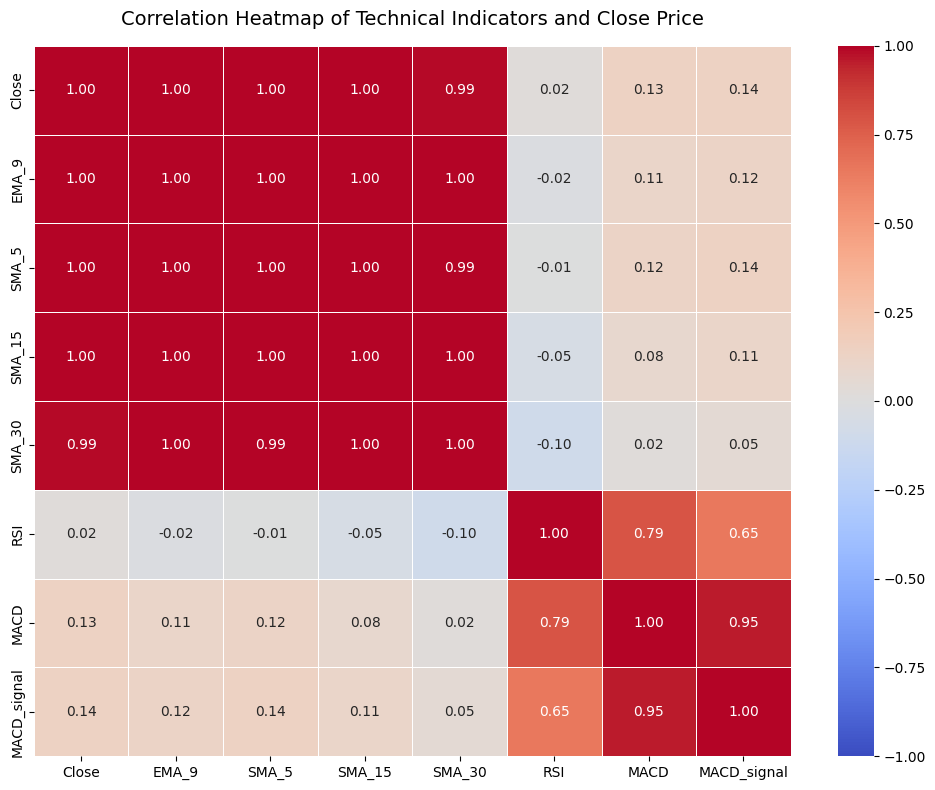

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['Close', 'EMA_9', 'SMA_5', 'SMA_15', 'SMA_30', 'RSI', 'MACD', 'MACD_signal']
corr_matrix = df[features_to_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)  
plt.title('Correlation Heatmap of Technical Indicators and Close Price', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap.png')
plt.show()